# Bike analysis

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys


In [35]:
trip_data = pd.read_csv(r"C:\Users\ingvivsu\OneDrive - NTNU\Master\FOMOsim\policies\sjovik_sund\simulation_results\final_tuning\sjovik_sund_alphas_1112251951_TD_000125_TEST03_seed_1_alpha01-05_fullweek_0.250_results_trip_requests_seed_1.csv")
    
#print account of trips per bike and their assosicated criticality for each trip
bike_trip_counts = trip_data['Bike ID'].value_counts()
print("Trip counts per bike:")
print(bike_trip_counts)
bike_criticality = trip_data.groupby('Bike ID')['Previous Bike Criticality']
print("\nAverage criticality per bike:")
print(bike_criticality)

Trip counts per bike:
Bike ID
B324    35
B704    34
B255    33
B708    33
B399    33
        ..
B447     3
B69      3
B28      2
B401     2
B24      1
Name: count, Length: 766, dtype: int64

Average criticality per bike:


In [36]:
# Check what columns are in the trip data
print("Available columns in trip_data:")
print(trip_data.columns.tolist())
print("\nFirst few rows:")
print(trip_data.head())

Available columns in trip_data:
['Seed', 'Alpha', 'Day', 'Hour', 'Minute', 'Time (minutes)', 'Station ID', 'Success', 'Failure Reason', 'Did Roam', 'Arrival Station ID', 'Travel Time (minutes)', 'Bike ID', 'Previous Bike Criticality', 'Post-Trip Bike Criticality']

First few rows:
   Seed  Alpha  Day  Hour  Minute  Time (minutes) Station ID  Success  \
0     1   0.25    0     7       0             420         S2     True   
1     1   0.25    0     7       0             420        S51     True   
2     1   0.25    0     7       1             421        S64     True   
3     1   0.25    0     7       2             422        S22     True   
4     1   0.25    0     7       2             422        S28     True   

  Failure Reason  Did Roam Arrival Station ID  Travel Time (minutes) Bike ID  \
0            NaN     False                 S7                   3.05     B17   
1            NaN     False                S52                  11.15    B572   
2            NaN     False             

In [37]:
colors = [
    ("Pale Fern", "#D9E5D6"),
    ("Sage Green", "#84A579"),
    ("Dark Spruce", "#344E41"),
    ("Warm Red", "#D1495B"),
    ("Ochre Gold", "#EDAE49"),
    ("Blue Accent", "#526ECA"),  
    ("Mist Grey", "#E6E6E6"),
]


Trip data for Bike ID B451:
       Day  Hour  Minute  Time (minutes) Station ID Arrival Station ID  \
179      0     8      12             492        S40                S40   
2273     0    17      50            1070        S10                S62   
2723     0    21      42            1302        S62                S52   
4004     1    11      44            2144        S62                S49   
4462     1    13      49            2269        S64                S58   
5411     1    17      22            2482        S58                S62   
5850     2     4      21            3141        S62                S60   
6886     2    10      43            3523        S27                S29   
6906     2    10      51            3531        S29                S35   
7133     2    12       2            3602        S35                S42   
7834     2    14      22            3742        S42                S61   
8051     2    15       3            3783        S61                S60   
10068    

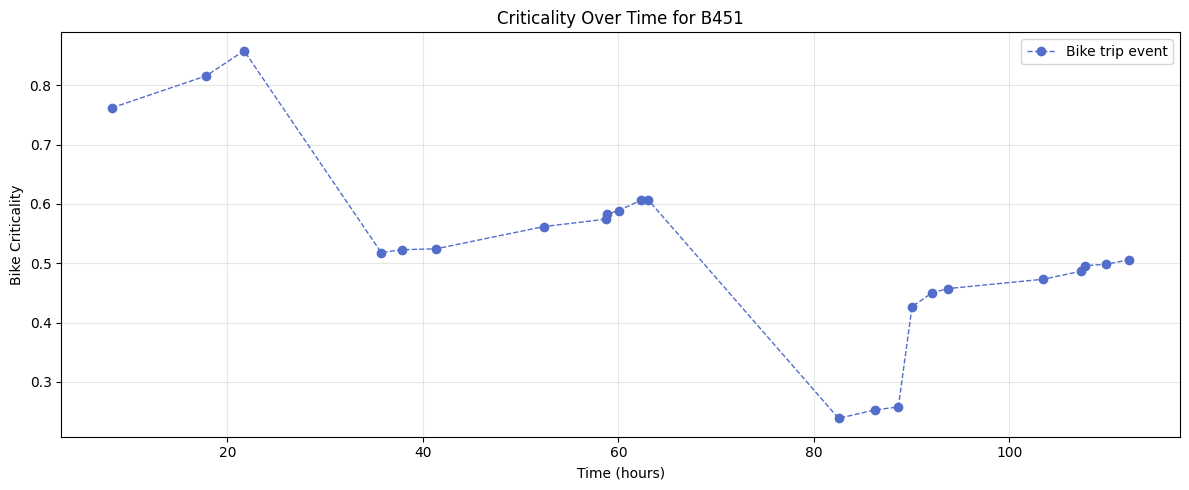


Criticality Statistics for B451:
Mean: 0.5246
Min: 0.2385
Max: 0.8583
Std: 0.1553


In [56]:
# Analyze how criticality changed over time for a specific bike
bike_id = "B451"
bike_data = trip_data[trip_data['Bike ID'] == bike_id].copy()
bike_data = bike_data.sort_values('Time (minutes)')

print(f"\nTrip data for Bike ID {bike_id}:")
print(bike_data[['Day', 'Hour', 'Minute', 'Time (minutes)', 'Station ID', 'Arrival Station ID', 'Previous Bike Criticality']])

# Plot criticality over time
plt.figure(figsize=(12, 5))
plt.plot(bike_data['Time (minutes)'] / 60, bike_data['Previous Bike Criticality'], marker='o', linestyle='dashed', linewidth=1, color=colors[5][1], markerfacecolor=colors[5][1], label='Bike trip event')
plt.xlabel('Time (hours)')
plt.ylabel('Bike Criticality')
plt.title(f'Criticality Over Time for {bike_id}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'bike_criticality_{bike_id}.svg', format='svg', bbox_inches='tight')
plt.show()

print(f"\nCriticality Statistics for {bike_id}:")
print(f"Mean: {bike_data['Previous Bike Criticality'].mean():.4f}")
print(f"Min: {bike_data['Previous Bike Criticality'].min():.4f}")
print(f"Max: {bike_data['Previous Bike Criticality'].max():.4f}")
print(f"Std: {bike_data['Previous Bike Criticality'].std():.4f}")

Bikes with most criticality variation (top 10):
              std  count      mean
Bike ID                           
B23      0.466158      3  0.622933
B748     0.379353     14  0.488936
B178     0.378125     16  0.505387
B364     0.373266     17  0.483382
B693     0.371911      8  0.359200
B381     0.360474     20  0.473335
B221     0.358973     17  0.493976
B293     0.357629     15  0.494720
B613     0.341626     19  0.521658
B234     0.330676     21  0.600424


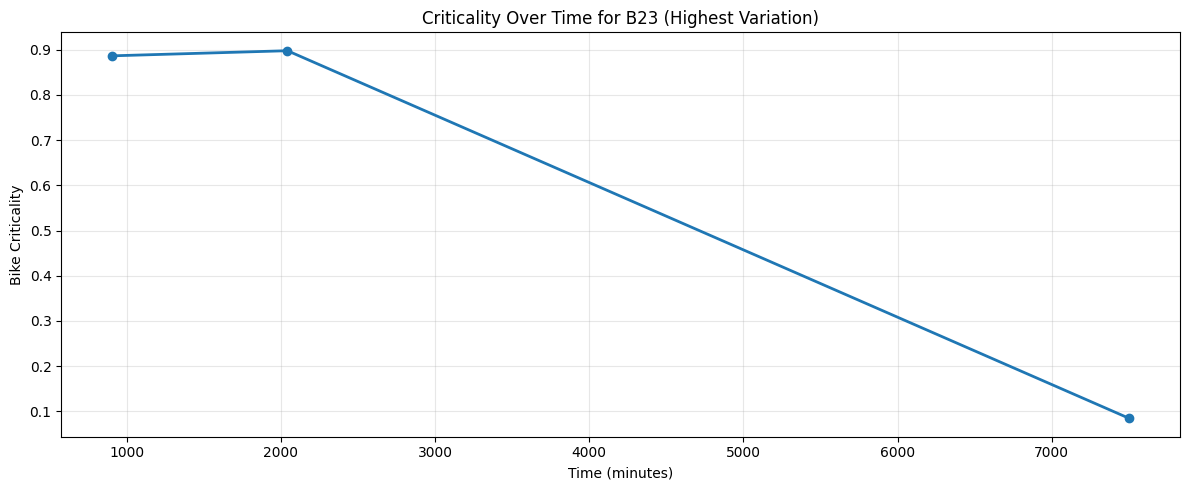

In [39]:
# Find bikes with varying criticality
bike_criticality_variance = trip_data.groupby('Bike ID')['Previous Bike Criticality'].agg(['std', 'count', 'mean'])
bike_criticality_variance = bike_criticality_variance[bike_criticality_variance['count'] > 1]
bike_criticality_variance = bike_criticality_variance.sort_values('std', ascending=False)

print("Bikes with most criticality variation (top 10):")
print(bike_criticality_variance.head(10))

# Plot a bike with high variation
if len(bike_criticality_variance) > 0 and bike_criticality_variance.iloc[0]['std'] > 0:
    most_varying_bike = bike_criticality_variance.index[0]
    varying_bike_data = trip_data[trip_data['Bike ID'] == most_varying_bike].copy()
    varying_bike_data = varying_bike_data.sort_values('Time (minutes)')
    
    plt.figure(figsize=(12, 5))
    plt.plot(varying_bike_data['Time (minutes)'], varying_bike_data['Previous Bike Criticality'], marker='o', linestyle='-', linewidth=2)
    plt.xlabel('Time (minutes)')
    plt.ylabel('Bike Criticality')
    plt.title(f'Criticality Over Time for {most_varying_bike} (Highest Variation)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo bikes show criticality variation - all criticalities appear to be static.")

Bikes with at least 2 direction changes (e.g., up->down->up pattern):
Found 378 bikes with this pattern

1. B558: 6 changes, 19 trips, range: 0.1584 - 0.2704
   Criticality sequence: ['0.2407', '0.2541', '0.2704', '0.1584', '0.1872', '0.2127', '0.2283', '0.2351', '0.2423', '0.2504', '0.1937', '0.2072', '0.1653', '0.1701', '0.1829', '0.1862', '0.1967', '0.2153', '0.2340']
2. B204: 6 changes, 29 trips, range: 0.1893 - 0.7266
   Criticality sequence: ['0.6951', '0.7103', '0.7266', '0.1893', '0.1935', '0.2239', '0.2280', '0.2551', '0.2895', '0.2072', '0.2177', '0.2316', '0.2376', '0.2566', '0.2590', '0.2654', '0.2664', '0.2809', '0.3331', '0.3539', '0.3582', '0.3732', '0.4963', '0.2952', '0.3030', '0.3131', '0.3194', '0.3835', '0.3977']
3. B644: 5 changes, 21 trips, range: 0.2163 - 0.6956
   Criticality sequence: ['0.4692', '0.4902', '0.4999', '0.5103', '0.5197', '0.5344', '0.5412', '0.5503', '0.5922', '0.6123', '0.6396', '0.6602', '0.6723', '0.6501', '0.6521', '0.6846', '0.6956', '0.6397'

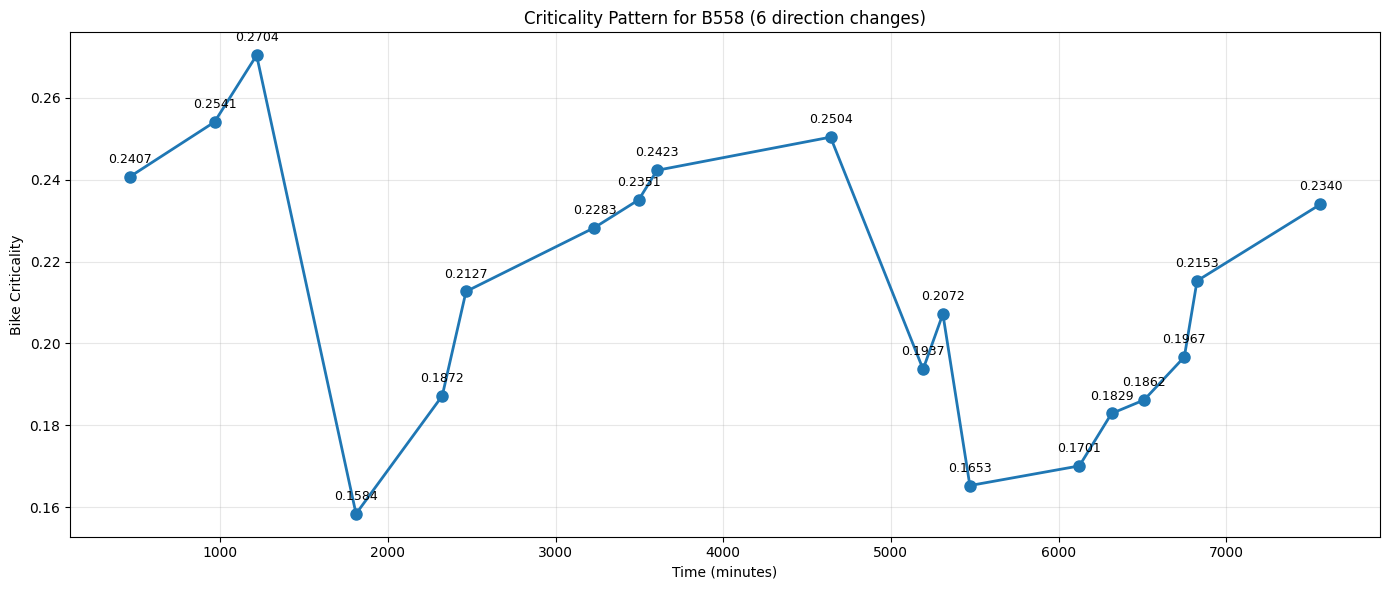

In [40]:
# Find bikes with direction changes in criticality (up -> down -> up pattern)
def count_direction_changes(criticality_values):
    """Count how many times criticality changes direction (increasing to decreasing or vice versa)"""
    if len(criticality_values) < 3:
        return 0
    
    changes = 0
    prev_direction = None
    
    for i in range(1, len(criticality_values)):
        diff = criticality_values[i] - criticality_values[i-1]
        
        if diff > 0.0001:  # Going up (with small tolerance for floating point)
            current_direction = 'up'
        elif diff < -0.0001:  # Going down
            current_direction = 'down'
        else:  # No change
            continue
            
        if prev_direction is not None and current_direction != prev_direction:
            changes += 1
            
        prev_direction = current_direction
    
    return changes

# Analyze direction changes for each bike
bike_direction_changes = []

for bike_id in trip_data['Bike ID'].unique():
    bike_trips = trip_data[trip_data['Bike ID'] == bike_id].sort_values('Time (minutes)')
    criticalities = bike_trips['Previous Bike Criticality'].values
    
    if len(criticalities) >= 3:
        num_changes = count_direction_changes(criticalities)
        if num_changes >= 2:  # At least 2 direction changes (e.g., up->down->up)
            bike_direction_changes.append({
                'Bike ID': bike_id,
                'Direction Changes': num_changes,
                'Num Trips': len(criticalities),
                'Criticality Range': f"{criticalities.min():.4f} - {criticalities.max():.4f}",
                'Criticalities': criticalities.tolist()
            })

# Sort by number of direction changes
bike_direction_changes.sort(key=lambda x: x['Direction Changes'], reverse=True)

print(f"Bikes with at least 2 direction changes (e.g., up->down->up pattern):")
print(f"Found {len(bike_direction_changes)} bikes with this pattern\n")

if len(bike_direction_changes) > 0:
    for i, bike_info in enumerate(bike_direction_changes[:10]):  # Show top 10
        print(f"{i+1}. {bike_info['Bike ID']}: {bike_info['Direction Changes']} changes, "
              f"{bike_info['Num Trips']} trips, range: {bike_info['Criticality Range']}")
        print(f"   Criticality sequence: {[f'{c:.4f}' for c in bike_info['Criticalities']]}")
    
    # Plot the first bike with direction changes
    print(f"\nPlotting criticality pattern for {bike_direction_changes[0]['Bike ID']}:")
    
    bike_id = bike_direction_changes[0]['Bike ID']
    bike_trips = trip_data[trip_data['Bike ID'] == bike_id].sort_values('Time (minutes)')
    
    plt.figure(figsize=(14, 6))
    plt.plot(bike_trips['Time (minutes)'], bike_trips['Previous Bike Criticality'], 
             marker='o', linestyle='-', linewidth=2, markersize=8)
    
    # Annotate each point with its value
    for idx, row in bike_trips.iterrows():
        plt.annotate(f'{row["Previous Bike Criticality"]:.4f}', 
                    xy=(row['Time (minutes)'], row['Previous Bike Criticality']),
                    xytext=(0, 10), textcoords='offset points', 
                    ha='center', fontsize=9)
    
    plt.xlabel('Time (minutes)')
    plt.ylabel('Bike Criticality')
    plt.title(f'Criticality Pattern for {bike_id} ({bike_direction_changes[0]["Direction Changes"]} direction changes)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No bikes found with direction changes in criticality.")